# League of Legends Match Predictor 


## Project Overview

League of Legends generates extensive data from matches, providing an excellent opportunity to apply machine learning techniques to real-world scenarios. This project builds a logistic regression model to predict match outcomes.

Use the [league_of_legends_data_large.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv) file to perform the tasks.  



In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import itertools

In [3]:
# Load the dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv"
data = pd.read_csv(url)

# Split data into features and target
X = data.drop('win', axis=1)
y = data['win']

# Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

print("Dataset loaded successfully!")
print(f"Features: {X.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Dataset loaded successfully!
Features: 8
Training samples: 800
Testing samples: 200


In [4]:
# Define the Logistic Regression Model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Initialize the Model, Loss Function, and Optimizer
input_dim = X_train.shape[1]
model = LogisticRegressionModel(input_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

print("Logistic Regression Model created successfully!")
print(f"Input dimension: {input_dim}")
print(model)


Logistic Regression Model created successfully!
Input dimension: 8
LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


In [5]:
# Set Number of Epochs
epochs = 1000

print("Training started...")
# Training Loop
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Model Evaluation
model.eval()
with torch.no_grad():
    train_outputs = model(X_train_tensor)
    train_predicted = (train_outputs >= 0.5).float()
    train_accuracy = (train_predicted == y_train_tensor).float().mean()
    
    test_outputs = model(X_test_tensor)
    test_predicted = (test_outputs >= 0.5).float()
    test_accuracy = (test_predicted == y_test_tensor).float().mean()

print(f'\nTraining Accuracy: {train_accuracy.item():.4f}')
print(f'Test Accuracy: {test_accuracy.item():.4f}')


Training started...
Epoch [100/1000], Loss: 0.7278
Epoch [200/1000], Loss: 0.7125
Epoch [300/1000], Loss: 0.7025
Epoch [400/1000], Loss: 0.6962
Epoch [500/1000], Loss: 0.6921
Epoch [600/1000], Loss: 0.6896
Epoch [700/1000], Loss: 0.6880
Epoch [800/1000], Loss: 0.6870
Epoch [900/1000], Loss: 0.6864
Epoch [1000/1000], Loss: 0.6860

Training Accuracy: 0.5512
Test Accuracy: 0.4600


In [6]:
# Set Up the Optimizer with L2 Regularization
optimizer_l2 = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01)

# Train the Model with L2 Regularization
epochs = 1000
model.train()

print("Training with L2 Regularization...")
for epoch in range(epochs):
    optimizer_l2.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer_l2.step()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Evaluate the Optimized Model
model.eval()
with torch.no_grad():
    train_outputs_l2 = model(X_train_tensor)
    train_predicted_l2 = (train_outputs_l2 >= 0.5).float()
    train_accuracy_l2 = (train_predicted_l2 == y_train_tensor).float().mean()
    
    test_outputs_l2 = model(X_test_tensor)
    test_predicted_l2 = (test_outputs_l2 >= 0.5).float()
    test_accuracy_l2 = (test_predicted_l2 == y_test_tensor).float().mean()

print(f'\nTraining Accuracy with L2: {train_accuracy_l2.item():.4f}')
print(f'Test Accuracy with L2: {test_accuracy_l2.item():.4f}')

Training with L2 Regularization...
Epoch [100/1000], Loss: 0.6857
Epoch [200/1000], Loss: 0.6855
Epoch [300/1000], Loss: 0.6854
Epoch [400/1000], Loss: 0.6854
Epoch [500/1000], Loss: 0.6853
Epoch [600/1000], Loss: 0.6853
Epoch [700/1000], Loss: 0.6853
Epoch [800/1000], Loss: 0.6853
Epoch [900/1000], Loss: 0.6853
Epoch [1000/1000], Loss: 0.6853

Training Accuracy with L2: 0.5450
Test Accuracy with L2: 0.5000


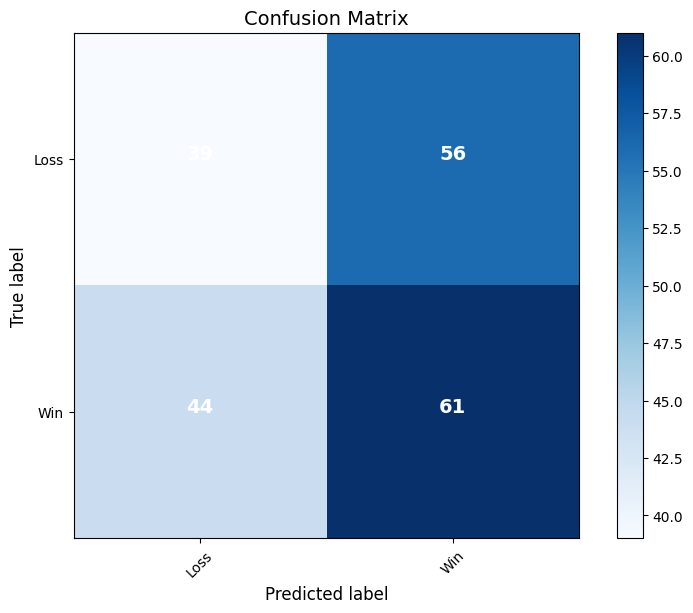


Classification Report:
              precision    recall  f1-score   support

        Loss       0.47      0.41      0.44        95
         Win       0.52      0.58      0.55       105

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.50      0.50      0.50       200



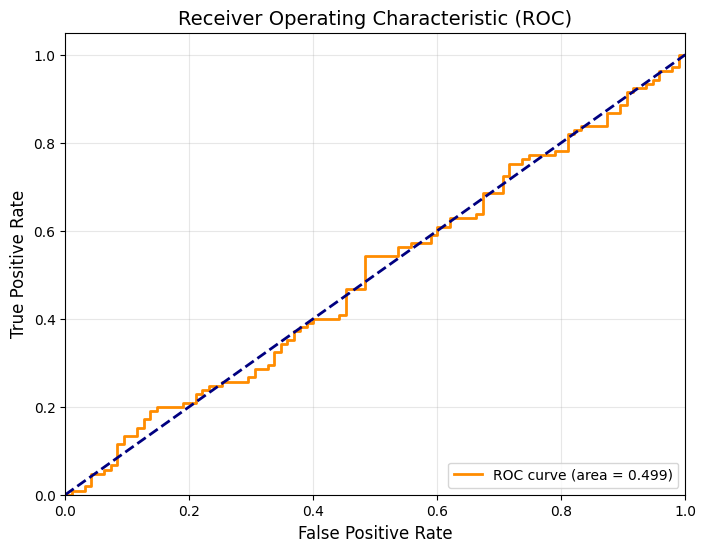

AUC Score: 0.4992


In [7]:
# Convert predictions to binary labels
y_pred_test_labels = (test_outputs_l2 >= 0.5).float().numpy()
y_test_numpy = y_test_tensor.numpy()

# ===== CONFUSION MATRIX =====
cm = confusion_matrix(y_test_numpy, y_pred_test_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=14)
plt.colorbar()
tick_marks = range(2)
plt.xticks(tick_marks, ['Loss', 'Win'], rotation=45)
plt.yticks(tick_marks, ['Loss', 'Win'])

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center", 
             color="white" if cm[i, j] > thresh else "black",
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.ylabel('True label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.show()

# ===== CLASSIFICATION REPORT =====
print("\nClassification Report:")
print(classification_report(y_test_numpy, y_pred_test_labels, 
                           target_names=['Loss', 'Win']))

# ===== ROC CURVE =====
fpr, tpr, thresholds = roc_curve(y_test_numpy, test_outputs_l2.numpy())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [8]:
# Save the model
torch.save(model.state_dict(), 'league_model.pth')
print("Model saved as 'league_model.pth'")

# Load the model
model_loaded = LogisticRegressionModel(input_dim)
model_loaded.load_state_dict(torch.load('league_model.pth'))
print("Model loaded successfully")

# Ensure the loaded model is in evaluation mode
model_loaded.eval()

# Evaluate the loaded model
with torch.no_grad():
    loaded_test_outputs = model_loaded(X_test_tensor)
    loaded_test_predicted = (loaded_test_outputs >= 0.5).float()
    loaded_accuracy = (loaded_test_predicted == y_test_tensor).float().mean()
    
    original_accuracy = test_accuracy_l2.item()

print(f'\nOriginal Model Test Accuracy: {original_accuracy:.4f}')
print(f'Loaded Model Test Accuracy: {loaded_accuracy.item():.4f}')
print(f'Models match: {abs(original_accuracy - loaded_accuracy.item()) < 0.0001}')


Model saved as 'league_model.pth'
Model loaded successfully

Original Model Test Accuracy: 0.5000
Loaded Model Test Accuracy: 0.5000
Models match: True


In [9]:
# Define Learning Rates
learning_rates = [0.01, 0.05, 0.1]
results = []

print("Hyperparameter Tuning Started...")
print("-" * 50)

for lr in learning_rates:
    # Reinitialize the model for each learning rate
    model_tune = LogisticRegressionModel(input_dim)
    criterion_tune = nn.BCELoss()
    optimizer_tune = optim.SGD(model_tune.parameters(), lr=lr)
    
    # Train the model
    epochs_tune = 100
    for epoch in range(epochs_tune):
        model_tune.train()
        optimizer_tune.zero_grad()
        outputs = model_tune(X_train_tensor)
        loss = criterion_tune(outputs, y_train_tensor)
        loss.backward()
        optimizer_tune.step()
    
    # Evaluate on test set
    model_tune.eval()
    with torch.no_grad():
        test_outputs = model_tune(X_test_tensor)
        test_predicted = (test_outputs >= 0.5).float()
        test_acc = (test_predicted == y_test_tensor).float().mean()
        
    results.append((lr, test_acc.item()))
    print(f'Learning Rate: {lr} -> Test Accuracy: {test_acc.item():.4f}')

# Report the best learning rate
print("-" * 50)
best_lr, best_acc = max(results, key=lambda x: x[1])
print(f'\n★ BEST LEARNING RATE: {best_lr} with Test Accuracy: {best_acc:.4f}')

Hyperparameter Tuning Started...
--------------------------------------------------
Learning Rate: 0.01 -> Test Accuracy: 0.5150
Learning Rate: 0.05 -> Test Accuracy: 0.5300
Learning Rate: 0.1 -> Test Accuracy: 0.4850
--------------------------------------------------

★ BEST LEARNING RATE: 0.05 with Test Accuracy: 0.5300



Feature Importance (Sorted):
     Feature  Importance
 gold_earned    0.169460
       kills    0.121867
wards_placed    0.100400
      deaths   -0.003900
          cs   -0.009716
     assists   -0.015205
damage_dealt   -0.015394
wards_killed   -0.029260


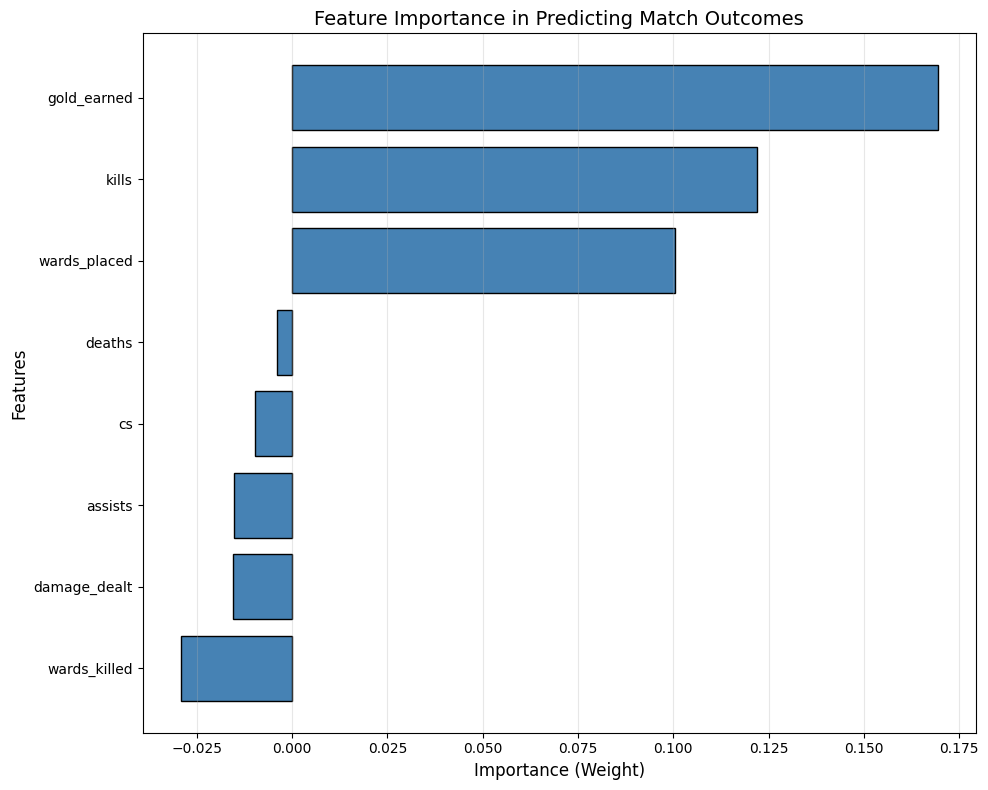


Top 5 Most Influential Features:
     Feature  Importance
 gold_earned    0.169460
       kills    0.121867
wards_placed    0.100400
wards_killed    0.029260
damage_dealt    0.015394


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract the weights of the linear layer
weights = model.linear.weight.data.numpy().flatten()
features = X.columns

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': features, 'Importance': weights})
feature_importance_sorted = feature_importance.sort_values(by='Importance', ascending=False)

print("\nFeature Importance (Sorted):")
print("=" * 50)
print(feature_importance_sorted.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_sorted['Feature'], feature_importance_sorted['Importance'], 
         color='steelblue', edgecolor='black')
plt.xlabel('Importance (Weight)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance in Predicting Match Outcomes', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Absolute importance
feature_importance_abs = pd.DataFrame({'Feature': features, 'Importance': np.abs(weights)})
feature_importance_abs = feature_importance_abs.sort_values(by='Importance', ascending=False)

print("\nTop 5 Most Influential Features:")
print("=" * 50)
print(feature_importance_abs.head(5).to_string(index=False))
